# Caffarelli regularity and non-convex target geometry

This notebook generates `fig:monge-caffarelli-nonconvex-map`.  Caffarelli's regularity theorem assumes, among other hypotheses, that the source and target domains are uniformly convex.  The purpose of this figure is to visualize why target geometry matters: a discrete quadratic optimal map from a disk to a non-convex bean-shaped domain sends smooth concentric source circles to strongly distorted curves.

The computation is deliberately elementary.  We sample the source disk by nearly area-uniform concentric rings, sample a smooth bean-shaped target with a low-discrepancy sequence, and solve the equal-weight assignment problem
$$
    rac1N\,\sum_{i=1}^N \delta_{x_i}
    \longrightarrow
    rac1N\,\sum_{j=1}^N \delta_{y_j},
    \qquad
    \min_{\sigma\in\mathfrak S_N}\sum_i \|x_i-y_{\sigma(i)}\|^2 .
$$
The right panel connects the images of points belonging to the same source circle, in source angular order.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        ROOT = candidate.parent if candidate.name == "notebooks-figures" else candidate
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import to_rgb
from matplotlib.path import Path as MplPath
from scipy.optimize import linear_sum_assignment
from scipy.stats import qmc

from figure_style import (
    RED,
    BLUE,
    VIOLET,
    GRAY,
    LIGHT_GRAY,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "monge-caffarelli-nonconvex-map"
OUT = figure_dir(NAME)
THUMB = ROOT / "notebooks-figures" / "thumbnails" / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)

## Source and target samples

The source points lie on concentric circles.  The number of points on a circle is proportional to its radius, so each annulus receives approximately its Euclidean area.  The target is a smooth kidney-shaped bean domain, curved like a fat banana; it is non-convex because of the indentation on its inner side.

In [2]:
def rotation_matrix(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])


def disk_concentric_sample(n_rings=30, circumference_density=94):
    """Nearly area-uniform points on concentric circles in the unit disk."""
    rings = []
    ring_id = []
    angle = []
    radii = np.sqrt((np.arange(n_rings) + 0.5) / n_rings)
    counts = np.maximum(10, np.round(circumference_density * radii).astype(int))
    for k, (r, m) in enumerate(zip(radii, counts)):
        theta = 2 * np.pi * np.arange(m) / m + (0.37 * k) % (2 * np.pi / m)
        rings.append(np.column_stack([r * np.cos(theta), r * np.sin(theta)]))
        ring_id.append(np.full(m, k, dtype=int))
        angle.append(theta)
    return np.vstack(rings), np.concatenate(ring_id), np.concatenate(angle), radii


def bean_boundary(n=1200):
    """Boundary of a smooth, visibly non-convex bean-shaped domain."""
    theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
    x = 1.18 * np.cos(theta) + 0.34 * np.cos(2 * theta) - 0.18 * np.cos(3 * theta) - 0.08
    y = 0.70 * np.sin(theta) * (1.0 + 0.34 * np.cos(theta)) - 0.12 * np.sin(2 * theta)
    # A nonlinear horizontal bend creates a pronounced inward dent without
    # making a self-intersecting or crescent-shaped target.
    x = x + 0.64 * (y**2 - 0.24) - 0.10 * y
    y = y + 0.10 * np.sin(theta) * np.cos(theta)
    boundary = np.column_stack([x, y])
    rot = rotation_matrix(-0.22)
    boundary = boundary @ rot.T
    boundary -= boundary.mean(axis=0, keepdims=True)
    boundary *= np.array([1.08, 1.00])
    return boundary

def sample_inside_path(boundary, n, seed=2029):
    """Low-discrepancy uniform sample inside a planar path."""
    path = MplPath(boundary)
    lo = boundary.min(axis=0) - 0.04
    hi = boundary.max(axis=0) + 0.04
    sampler = qmc.Sobol(d=2, scramble=True, seed=seed)
    u = sampler.random_base2(17)
    candidates = lo + (hi - lo) * u
    inside = path.contains_points(candidates)
    pts = candidates[inside]
    if len(pts) < n:
        raise RuntimeError(f"Only {len(pts)} accepted target points for n={n}.")
    return pts[:n]

X, ring_id, source_angle, radii = disk_concentric_sample()
boundary = bean_boundary()
Y = sample_inside_path(boundary, len(X))
print(f"number of source/target points: {len(X)}")

number of source/target points: 1882


## Discrete quadratic OT map

All points carry the same mass.  The assignment problem is the finite Monge problem for the empirical measures, and is solved exactly by the Hungarian algorithm.  The resulting permutation defines the displayed map.

In [3]:
cost = np.sum((X[:, None, :] - Y[None, :, :]) ** 2, axis=2)
rows, cols = linear_sum_assignment(cost)
Y_map = np.empty_like(X)
Y_map[rows] = Y[cols]
print(f"assignment cost: {cost[rows, cols].mean():.4f}")

# Colors encode the source radius, so that each displayed curve can be tracked
# from the disk to its image in the bean-shaped target.
ring_t = (radii - radii.min()) / (radii.max() - radii.min())
ring_colors = np.array([interp_color(float(t), RED, BLUE) for t in ring_t])
point_colors = ring_colors[ring_id]


def smooth_closed_curve(points, window=5, passes=2):
    """Small periodic smoothing used only for the visual guide curves."""
    q = np.asarray(points, dtype=float)
    if len(q) < 2 * window + 1:
        return q
    kernel = np.ones(window) / window
    for _ in range(passes):
        pad = window // 2
        extended = np.vstack([q[-pad:], q, q[:pad]])
        q = np.column_stack([
            np.convolve(extended[:, 0], kernel, mode="valid"),
            np.convolve(extended[:, 1], kernel, mode="valid"),
        ])
    return q

assignment cost: 0.0526


## Rendering

The PDFs contain no embedded titles.  The source panel shows the concentric source circles.  The target panel shows the image of each circle under the computed assignment; the thin colored curves are visual guides obtained by connecting mapped samples in the original angular order.

In [4]:
def equalize_limits(ax, points, pad=0.08):
    pts = np.asarray(points)
    lo, hi = pts.min(axis=0), pts.max(axis=0)
    center = 0.5 * (lo + hi)
    span = max(hi[0] - lo[0], hi[1] - lo[1]) * (1 + pad)
    ax.set_xlim(center[0] - span / 2, center[0] + span / 2)
    ax.set_ylim(center[1] - span / 2, center[1] + span / 2)
    ax.set_aspect("equal")
    remove_axes(ax)


def draw_source_panel(path):
    fig, ax = plt.subplots(figsize=(2.55, 2.55))
    theta = np.linspace(0, 2 * np.pi, 600)
    ax.plot(np.cos(theta), np.sin(theta), color="#2b2b2b", lw=0.95, zorder=4)
    for k, r in enumerate(radii):
        idx = np.flatnonzero(ring_id == k)
        order = np.argsort(source_angle[idx])
        P = X[idx][order]
        Q = np.vstack([P, P[:1]])
        lw = 0.42 if k % 2 else 0.58
        ax.plot(Q[:, 0], Q[:, 1], color=ring_colors[k], lw=lw, alpha=0.92, zorder=2)
    equalize_limits(ax, X, pad=0.16)
    save_pdf(fig, path, pad_inches=0.015)
    plt.close(fig)


def draw_target_panel(path):
    fig, ax = plt.subplots(figsize=(3.15, 2.55))
    ax.fill(boundary[:, 0], boundary[:, 1], color="#f8f8f8", zorder=0)
    ax.plot(boundary[:, 0], boundary[:, 1], color="#2b2b2b", lw=0.95, zorder=5)
    for k in range(len(radii)):
        idx = np.flatnonzero(ring_id == k)
        order = np.argsort(source_angle[idx])
        P = Y_map[idx][order]
        P = smooth_closed_curve(P, window=5, passes=1)
        Q = np.vstack([P, P[:1]])
        lw = 0.52 if k % 2 else 0.70
        ax.plot(Q[:, 0], Q[:, 1], color=ring_colors[k], lw=lw, alpha=0.96, zorder=2)
    equalize_limits(ax, boundary, pad=0.12)
    save_pdf(fig, path, pad_inches=0.015)
    plt.close(fig)

source_pdf = OUT / "source-circles.pdf"
target_pdf = OUT / "bean-image-circles.pdf"
draw_source_panel(source_pdf)
draw_target_panel(target_pdf)
print(source_pdf.relative_to(ROOT))
print(target_pdf.relative_to(ROOT))

latex/figures/monge-caffarelli-nonconvex-map/source-circles.pdf
latex/figures/monge-caffarelli-nonconvex-map/bean-image-circles.pdf


## Thumbnail

The notebook also stores a small side-by-side PNG preview for the searchable gallery and GitHub rendering.

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(6.3, 2.65), gridspec_kw={"width_ratios": [1.0, 1.22]})
# Reuse the same drawing commands inline for a compact thumbnail.
ax = axes[0]
theta = np.linspace(0, 2 * np.pi, 600)
ax.plot(np.cos(theta), np.sin(theta), color="#2b2b2b", lw=0.95, zorder=4)
for k, r in enumerate(radii):
    idx = np.flatnonzero(ring_id == k)
    order = np.argsort(source_angle[idx])
    P = X[idx][order]
    Q = np.vstack([P, P[:1]])
    ax.plot(Q[:, 0], Q[:, 1], color=ring_colors[k], lw=0.42 if k % 2 else 0.58, alpha=0.92, zorder=2)
equalize_limits(ax, X, pad=0.16)

ax = axes[1]
ax.fill(boundary[:, 0], boundary[:, 1], color="#f8f8f8", zorder=0)
ax.plot(boundary[:, 0], boundary[:, 1], color="#2b2b2b", lw=0.95, zorder=5)
for k in range(len(radii)):
    idx = np.flatnonzero(ring_id == k)
    order = np.argsort(source_angle[idx])
    P = smooth_closed_curve(Y_map[idx][order], window=5, passes=1)
    Q = np.vstack([P, P[:1]])
    ax.plot(Q[:, 0], Q[:, 1], color=ring_colors[k], lw=0.52 if k % 2 else 0.70, alpha=0.96, zorder=2)
equalize_limits(ax, boundary, pad=0.12)

fig.subplots_adjust(wspace=0.035, left=0, right=1, bottom=0, top=1)
fig.savefig(THUMB, dpi=220, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)
print(THUMB.relative_to(ROOT))

notebooks-figures/thumbnails/monge-caffarelli-nonconvex-map.png


## Figure preview

The output below embeds the generated thumbnail so the figure renders directly on GitHub.

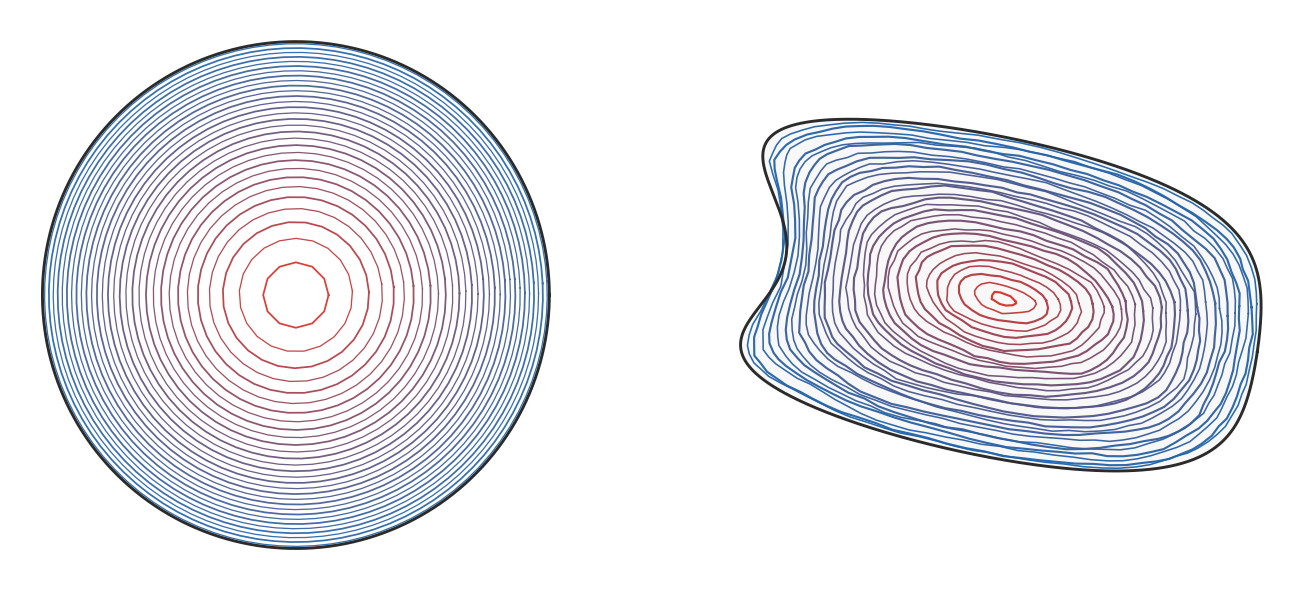

In [6]:
from IPython.display import Image as IPyImage, display
_thumb = Path("thumbnails/monge-caffarelli-nonconvex-map.png")
if not _thumb.exists():
    _thumb = ROOT / "notebooks-figures" / "thumbnails" / "monge-caffarelli-nonconvex-map.png"
display(IPyImage(filename=str(_thumb)))